<a href="https://colab.research.google.com/github/scardenol/Numerical_Analysis_2026/blob/main/Taller%201/1_simplex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taller 1 - Punto 1

Considere el problema de programación lineal estándar

\begin{gather*}
\max\; c^Tx \quad \text{s.a.} \quad Ax \leq b,\; x \geq 0
\end{gather*}

Donde:
* $c_{n \times 1}$ es el vector de costos o coeficientes de la fucnción objetivo.
* $x_{n \times 1}$ es el vector de variables de decisión.
* $A_{m \times n}$ es la matriz de coeficientes de las restricciones.
* $b_{m \times 1}$ es el vector de disponibilidad de recursos que limita las restricciones.

El objetivo es:
1) Programar el método Simplex que reciba como parámetros de entrada $c$, $A$, $b$.
2) Validar el ejemplo de **La Floristería** de clase.
3) Proponer otro arreglo floral para el ejercicio, agregarlo y solucionarlo.
4) Perturbar los vectores $b$ y $c$ del problema original y proponer un análisis de sensibilidad. Sería interesante poder observar:
    - El área de la región factible.
    - Perturbaciones suficientemente grandes para ver casos de salto de vértices (nuevo óptimo).

In [1]:
# Cargar librerías
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# 1) Método Simplex

Partiendo del problema de programación lineal estándar, se transforman las restricciones de desigualdad a igualdad al usar variables de holgura. Esto resulta en el problema equivalente:

\begin{gather*}
\max\; z= c^Tx \quad \text{s.a.} \quad Ax + s = b,\; x,s \geq 0
\end{gather*}

Donde $s_{m \times 1}$ es el vector de variables de holgura.

Note que:
* Cambian algunas dimensiones: $x_{(m+n)\times 1}$, $A_{m \times (m+n)}$ y $c_{(m+n)\times 1}$. Pero $b_{m \times 1}$ se mantiene igual.
* El sistema lineal en este punto tiene infinitas soluciones.

Por esta razón, pensamos en variables básicas $x_{B_{m \times 1}}$ y no-básicas $x_{N_{n \times 1}}$, buscando que $x_N = 0$ y reduciendo el sistema lineal a un problema de $m$ variables $\times$ $m$ ecuaciones. Esto implica que:
\begin{gather*}
x = [x_B \;|\; x_N]^T, \\
A = [A_B \;|\; A_N], \\
c = [c_B \;|\; c_N]^T,
\end{gather*}
Donde, se puede deducir que
\begin{gather*}
x_B = A_B^{-1}(b-A_N x_N),\\
z = c_B^Tx_B + c_N^Tx_N,\\
y^T = c_B^TA_B^{-1} \quad \text{(vector de precios sombra)}, \\
\bar{c}_j = y^TA_j - c_j \quad \text{(costos reducidos) con $j$ columna de la variable asociada}
\end{gather*}

y, de acuerdo con el **Criterio de Optimalidad**, si todos los costos reducidos de las variables no-básicas son $\geq0$, la solución (base) es óptima.

In [2]:
def simplex(A, b, c, verbose=True):
  """
  Método Simplex para resolver problemas de máximización de programación lineal
  en la forma estándar. Se asume que c,b son np.array 1D y A es np.array 2D.

  Entradas:
  - A: matriz de coeficientes de las restricciones.
  - b: vector de disponibilidad de recursos que limita las restricciones.
  - c: vector de costos o coeficientes de la función objetivo.
  - verbose: flag booleano que determina si se quiere imprimir el progreso del algoritmo.

  Salidas:
  - base: diccionario con la base óptima.
  - z: valor de la función objetivo en la base óptima.
  """
  # Revisar que los objetos sean los esperados con la dimensión esperada
  assert isinstance(A, np.ndarray), "A no es un array de numpy"
  assert isinstance(b, np.ndarray), "b no es un array de numpy"
  assert isinstance(c, np.ndarray), "c no es un array de numpy"

  assert A.ndim == 2, "A no es un array 2D"
  assert b.ndim == 1, "b no es un array1D"
  assert c.ndim == 1, "c no es un array 1D"

  # Extraer dimensiones m y n de la matriz A
  m, n = A.shape

  # Crear nombres para las variables de holgura (s_1, ..., s_m) y de decisión (x_1, ..., x_n)
  nombres = np.array([f"s_{i+1}" for i in range(m)] + [f"x_{j+1}" for j in range(n)])

  # Inicialización
  x_N = np.zeros(n)
  A_B = np.eye(m)
  A_N = A
  c_B = np.zeros(m)
  c_N = c
  A_B_inv = np.linalg.inv(A_B)
  x_B = A_B_inv @ (b - A_N @ x_N)
  iteracion = 0

  # Ciclo while que itera mientras no se haya alcanzado el óptimo
  while True:

    # Objetos con dimensión aumentada
    x = np.concatenate((x_B, x_N))
    A = np.concatenate((A_B, A_N), axis=1)
    c = np.concatenate((c_B, c_N))

    # Evaluar en la función objetivo z = c^Tx
    z = c.T @ x

    # Calcular la base actual
    base = {nombre.item(): round(valor.item(), 2) for nombre, valor in zip(nombres[:m], x_B)}

    # Imprimir progreso
    if verbose:
      print("="*91)
      print("="*40 + f"Iteración {iteracion}" + "="*40)
      print(f"Función objetivo: z = {z}")
      print(f"Base actual: x_B = {base}")

    # Calcular vector de precios sombra y^T = c_B^T A_B^{-1}
    y_T = c_B.T @ A_B_inv

    # Calcular vector de costos reducidos
    c_bar = y_T @ A - c
    print(f"Costos reducidos: c_bar = {np.round(c_bar, 2)}\n") if verbose else None

    # Verificar si la base es óptima (Criterio de Optimalidad) c_bar_N \geq 0
    if np.all(c_bar >= 0):
      # Extraer los valores de x_B asociados a los nombres con "x" y guardarlo
      # en un diccionario con cada nombre

      print(f"Óptimo alcanzado: x* = {base}") if verbose else None
      break
    else: # De lo contrario

      # Elegir el índice del costo reducido más negativo (mínimo)
      j = np.argmin(c_bar)

      # Extraer el elemento j de A
      A_j = A[:, j]

      # Calcular el  nuevo valor de la variable x_j
      v_j = np.divide(A_B_inv @ b, A_B_inv @ A_j) # Vector auxiliar v_j = (A_B_inv b) / (A_B_inv A_j)
      x_j = np.min(v_j) # nuevo valor de la variable x_j
      i = np.argmin(v_j) # índice del mínimo

      # Actualizar la base x_B = A_B^{-1}(b-A_j x_j)
      x_B = A_B_inv @ (b - x_j*A_j)

      # Actualizar vectores con la nueva base
      x_B[i] = x_j # entra la variable j a la base en la posición i
      c_B[i] = c[j] # entra el costo de la variable j en la posición i
      c_N[j-m] = 0 # elimina el costo de la variable j en la posición i

      # Actualizar la matriz A con la nueva base
      A[:, [i, j]] = A[:, [j, i]] # intercambiar columnas i y j de A
      nombres[[i, j]] = nombres[[j, i]] # hacer lo mismo para preservar el orden de los nombres

      A_B = A[:, :m] # extraer A_B
      A_N = A[:, m:] # extraer A_N
      A_B_inv = np.linalg.inv(A_B) # recalcular la inversa

      # Aumentar iteración
      iteracion += 1

  # Retornar los resultados
  return base, z.item()


# 2) Validación: ejemplo de La Floristería

José abrió una floristería que se llama *Chepeflower* que ofrece 2 tipos de arreglos florales $x_1$ y $x_2$ con las siguientes características:

<center>

||$x_1$|$x_2$|Disponibilidad|
|----|:----:|:----:|:----:|
|rosas|3|1|300|
|tulipanes|1|1|140|
|hibisco|1|3|300|
||\$2000|\$1000||

</center>

¿Cuántos arreglos tipo $x_1$ y $x_2$ hay que hacer para maximizar las ganancias?


**Problema en forma estándar**

Lo anterior se puede modelar como un problema de programación lineal en forma estándar:

\begin{align*}
\max\limits\; &z=2000x_1 + 1000x_2 \\
&\text{s.a.}\; \begin{cases} 3x_1 + x_2 \leq 300, \\
x_1 + x_2 \leq 140, \\ x_1 + 3x_2 \leq 300, \\ x_1, x_2 \geq 0 \end{cases}
\end{align*}

Note que el problema tiene 2 variables de decisión y 3 restricciones (además de la de no-negatividad). También, se puede escribir de manera más compacta como

\begin{gather*}
\max\; c^Tx \quad \text{s.a.} \quad Ax \leq b,\; x \geq 0 \\[6pt]
x = \begin{bmatrix}x_1\\x_2\end{bmatrix}, \quad A = \begin{bmatrix}3&1\\1&1\\1&3\end{bmatrix},\quad b = \begin{bmatrix}300\\140\\300\end{bmatrix}, \quad c = \begin{bmatrix}2000\\1000\end{bmatrix}
\end{gather*}


In [3]:
# Parámetros de entrada
A = np.array([[3, 1], [1, 1], [1, 3]])
b = np.array([300, 140, 300])
c = np.array([2000, 1000])

In [4]:
# Correr el algoritmo para encontrar el óptimo
x_opt, z_opt = simplex(A, b, c)

========================================Iteración 0========================================
Función objetivo: z = 0.0
Base actual: x_B = {'s_1': 300.0, 's_2': 140.0, 's_3': 300.0}
Costos reducidos: c_bar = [    0.     0.     0. -2000. -1000.]

========================================Iteración 1========================================
Función objetivo: z = 200000.0
Base actual: x_B = {'x_1': 100.0, 's_2': 40.0, 's_3': 200.0}
Costos reducidos: c_bar = [   0.      0.      0.    666.67 -333.33]

========================================Iteración 2========================================
Función objetivo: z = 220000.0
Base actual: x_B = {'x_1': 80.0, 'x_2': 60.0, 's_3': 40.0}
Costos reducidos: c_bar = [  0.   0.   0. 500. 500.]

Óptimo alcanzado: x* = {'x_1': 80.0, 'x_2': 60.0, 's_3': 40.0}


In [5]:
# Revisar los resultados
print(f"El óptimo alcanzado es ${z_opt} con la base {x_opt}")

El óptimo alcanzado es $220000.0 con la base {'x_1': 80.0, 'x_2': 60.0, 's_3': 40.0}


El óptimo es $x^*=\begin{bmatrix}x_1^*\\x_2^*\end{bmatrix}=\begin{bmatrix}80\\60\end{bmatrix}$. Esto significa que se deben hacer 80 arreglos tipo $x_1$ y 60 tipo $x_2$ para obtener una ganancia máxima de \$220,000 unidades monetarias. Adicionalmente, esto lleva a que sobren 40 hibiscos.

# 3) Nuevo arreglo floral
Se propone un tercer arreglo floral $x_3$ con las siguientes características:

<center>

||$x_1$|$x_2$|$x_3$|Disponibilidad|
|----|:----:|:----:|:----:|:----:|
|rosas|3|1|3|300|
|tulipanes|1|1|2|140|
|hibisco|1|3|1|300|
||\$2000|\$1000|\$3000||

</center>

Lo cual se modela como

\begin{gather*}
\max\; c^Tx \quad \text{s.a.} \quad Ax \leq b,\; x \geq 0 \\[6pt]
x = \begin{bmatrix}x_1\\x_2\\x_3\end{bmatrix}, \quad A = \begin{bmatrix}3&1&3\\1&1&2\\1&3&1\end{bmatrix},\quad b = \begin{bmatrix}300\\140\\300\end{bmatrix}, \quad c = \begin{bmatrix}2000\\1000\\2500\end{bmatrix}
\end{gather*}


In [6]:
# Parámetros de entrada
A2 = np.array([[3, 1, 3], [1, 1, 2], [1, 3, 1]])
b2 = np.array([300, 140, 300])
c2 = np.array([2000, 1000, 2500])

In [7]:
# Correr el algoritmo para encontrar el óptimo
x_opt2, z_opt2 = simplex(A2, b2, c2)

========================================Iteración 0========================================
Función objetivo: z = 0.0
Base actual: x_B = {'s_1': 300.0, 's_2': 140.0, 's_3': 300.0}
Costos reducidos: c_bar = [    0.     0.     0. -2000. -1000. -2500.]

========================================Iteración 1========================================
Función objetivo: z = 175000.0
Base actual: x_B = {'s_1': 90.0, 'x_3': 70.0, 's_3': 230.0}
Costos reducidos: c_bar = [   0.    0.    0. -750.  250. 1250.]

========================================Iteración 2========================================
Función objetivo: z = 220000.0
Base actual: x_B = {'x_1': 60.0, 'x_3': 40.0, 's_3': 200.0}
Costos reducidos: c_bar = [  0.   0.   0. 500.   0. 500.]

Óptimo alcanzado: x* = {'x_1': 60.0, 'x_3': 40.0, 's_3': 200.0}


In [8]:
# Revisar los resultados
print(f"El óptimo alcanzado es ${z_opt2} con la base {x_opt2}")

El óptimo alcanzado es $220000.0 con la base {'x_1': 60.0, 'x_3': 40.0, 's_3': 200.0}


El óptimo es $x^*=\begin{bmatrix}x_1^*\\x_2^*\\x_3^*\end{bmatrix}=\begin{bmatrix}60\\0\\40\end{bmatrix}$. Esto significa que se deben hacer 60 arreglos tipo $x_1$, 0 tipo $x_2$ y 40 tipo $x_3$ para obtener una ganancia máxima de \$220,000 unidades monetarias. Adicionalmente, esto lleva a que sobren 200 hibiscos.

# Visualización de la región de costo

Región factible evaluada en la función objetivo.
- Visualización en 2D con curvas de nivel.
- Visualización en 3D de la superficie.

In [9]:
# Función para visualizar la región factible del problema de programación min c^Tx s.a. Ax \leq b
def ver_region_factible(A, b, c, x1_range=(0, 100), x2_range=(0, 100), n=400, punto=None):
  # Crear una malla con la resolución pasada
  x1, x2 = np.linspace(*x1_range, n), np.linspace(*x2_range, n)
  X1, X2 = np.meshgrid(x1, x2)
  X = np.stack([X1, X2])

  # Evaluar Z en la malla
  Z = np.where((A @ X.reshape(2, -1)).reshape(-1, n, n) <= b[:, None, None],
                True, False).all(axis=0)
  Z = np.where(Z, (c @ X.reshape(2, -1)).reshape(n, n), np.nan)

  # Configruación inicial
  fig, ax = plt.subplots(figsize=(8, 8))

  # Mapa de calor de la región factible con barra de color
  mesh = ax.pcolormesh(X1, X2, Z, cmap='viridis', shading='auto')
  fig.colorbar(mesh, ax=ax, label='$z = c^Tx$')

  # Líneas de contorno para ver diferentes valores de Z además de la escala de color
  cs = ax.contour(X1, X2, Z, colors='white', linewidths=0.4, alpha=1)
  ax.clabel(cs, inline=True, fontsize=8, fmt='$%.0f')

  # Dibujar las líneas de cada restricción y mostrar las ecuaciones en la leyenda
  for i, ((a1, a2), b_i, color) in enumerate(
          zip(A, b, plt.rcParams['axes.prop_cycle'].by_key()['color'])):
      ax.contour(X1, X2, a1*X1 + a2*X2, levels=[b_i], colors=[color], linewidths=1)
      ax.plot([], [], color=color, lw=2, label=f'R{i+1}: {a1:.0f}$x_1$ + {a2:.0f}$x_2$ = {b_i:.0f}')

  # Si se pasa un punto dibujarlo en color rojo y agregar sus coordenadas y
  # valor de z en la leyenda
  if punto is not None:
      z_punto = c @ punto
      ax.scatter(*punto, color='red', zorder=5, s=30,
                  label=f'x*=({punto[0]}, {punto[1]}),  z=${z_punto:,.0f}')

  ax.set(xlabel='$x_1$', ylabel='$x_2$',
          title='Región factible, restricciones individuales y $z = c^Tx$',
          aspect='equal')
  ax.legend(loc='upper right', fontsize=8)
  plt.show()

In [10]:
def ver_region_factible_3d(A, b, c, x1_range=(0, 100), x2_range=(0, 100), n=100, punto=None):
  # Crear una malla con la resolución pasada
  x1, x2 = np.linspace(*x1_range, n), np.linspace(*x2_range, n)
  X1, X2 = np.meshgrid(x1, x2)
  X = np.stack([X1, X2])

  # Evaluar Z en la malla y enmascarar fuera de la región factible
  factible = (A @ X.reshape(2, -1)).reshape(-1, n, n) <= b[:, None, None]
  mask = factible.all(axis=0)
  Z_full = (c @ X.reshape(2, -1)).reshape(n, n)
  z_max = np.nanmax(np.where(mask, Z_full, np.nan))

  # Extraer solo los puntos factibles para Mesh3d
  # Mesh3d triangula los puntos directamente, evitando el aliasing
  # que produce Surface al cortar con np.nan en bordes diagonales
  x1_pts = X1[mask].flatten()
  x2_pts = X2[mask].flatten()
  z_pts  = Z_full[mask].flatten()

  # Triangulación de Delaunay sobre los puntos factibles
  from scipy.spatial import Delaunay
  points_2d = np.column_stack([x1_pts, x2_pts])
  tri = Delaunay(points_2d)

  fig = go.Figure()

  # Superficie de la región factible como malla triangulada
  fig.add_trace(go.Mesh3d(
      x=x1_pts, y=x2_pts, z=z_pts,
      i=tri.simplices[:, 0],
      j=tri.simplices[:, 1],
      k=tri.simplices[:, 2],
      intensity=z_pts,
      colorscale='viridis',
      opacity=0.85,
      colorbar=dict(title='z = cᵀx'),
      name='Región factible',
      showlegend=True
  ))

  # Colores para cada restricción
  colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
            '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

  for i, ((a1, a2), b_i, color) in enumerate(zip(A, b, colors)):

      # Calcular la línea de la restricción clippeada al rango del plot
      x1_line = np.linspace(*x1_range, 300)
      if a2 != 0:
          x2_line = (b_i - a1 * x1_line) / a2
      else:
          x1_line = np.full(300, b_i / a1)
          x2_line = np.linspace(*x2_range, 300)

      in_range = (x2_line >= x2_range[0]) & (x2_line <= x2_range[1])
      x1_line, x2_line = x1_line[in_range], x2_line[in_range]

      # Plano vertical de la restricción: apilar borde inferior (z=0) y
      # superior (z=z_max) para formar una pared limpia sin aliasing,
      # independientemente del ángulo de la línea
      x1_plane = np.vstack([x1_line, x1_line])
      x2_plane = np.vstack([x2_line, x2_line])
      z_plane  = np.vstack([np.zeros_like(x1_line), np.full_like(x1_line, z_max)])

      fig.add_trace(go.Surface(
          x=x1_plane, y=x2_plane, z=z_plane,
          surfacecolor=np.zeros_like(z_plane),
          colorscale=[[0, color], [1, color]],
          opacity=0.25,
          showscale=False,
          name=f'R{i+1}: {a1:.0f}x₁ + {a2:.0f}x₂ = {b_i:.0f}',
          showlegend=True
      ))

      # Proyección de la restricción en el plano base z=0
      fig.add_trace(go.Scatter3d(
          x=x1_line, y=x2_line, z=np.zeros_like(x1_line),
          mode='lines',
          line=dict(color=color, width=4),
          showlegend=False
      ))

  # Si se pasa un punto dibujarlo con una línea vertical hasta la superficie
  if punto is not None:
      z_punto = c @ punto
      fig.add_trace(go.Scatter3d(
          x=[punto[0]], y=[punto[1]], z=[z_punto],
          mode='markers+text',
          marker=dict(color='red', size=6, symbol='circle'),
          text=[f'x*=({punto[0]}, {punto[1]}), z={z_punto:,.0f}'],
          textposition='top center',
          name=f'x*=({punto[0]}, {punto[1]}), z={z_punto:,.0f}'
      ))
      # Línea vertical desde z=0 hasta el punto óptimo
      fig.add_trace(go.Scatter3d(
          x=[punto[0], punto[0]],
          y=[punto[1], punto[1]],
          z=[0, z_punto],
          mode='lines',
          line=dict(color='red', width=3, dash='dash'),
          showlegend=False
      ))

  fig.update_layout(
      title='Región factible y z = cᵀx',
      scene=dict(
          xaxis_title='x₁',
          yaxis_title='x₂',
          zaxis_title='z = cᵀx'
      ),
      legend=dict(x=0.75, y=0.9, font=dict(size=10)),
      width=900,
      height=750,
      margin=dict(l=0, r=0, t=40, b=0)
  )

  fig.show()

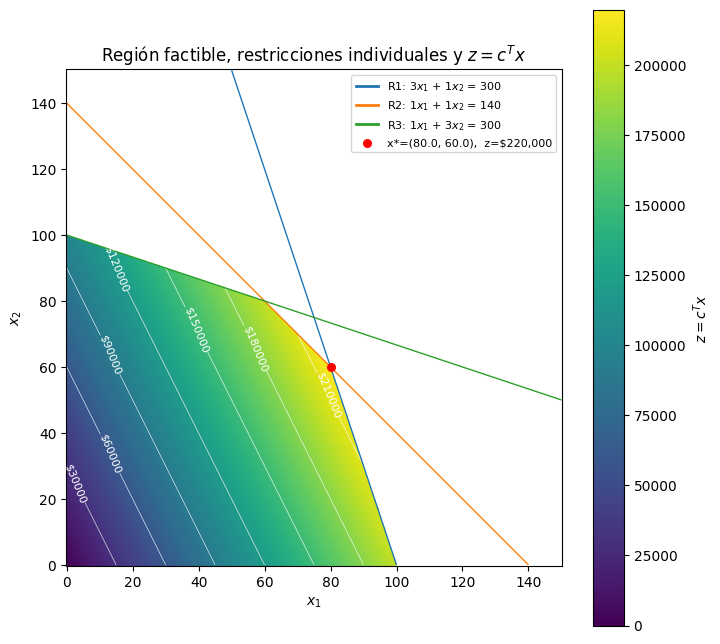

In [11]:
# Caso de la Floristería
A = np.array([[3, 1], [1, 1], [1, 3]])
b = np.array([300, 140, 300])
c = np.array([2000, 1000])
optimo = np.array([x_opt['x_1'], x_opt['x_2']]) # (x_1, x_2) = (80, 60)

ver_region_factible(A, b, c, x1_range=(0, 150), x2_range=(0, 150), punto=optimo)

In [12]:
# Visualizaciónn en 3D
ver_region_factible_3d(A, b, c, x1_range=(0, 150), x2_range=(0, 150), punto=optimo)

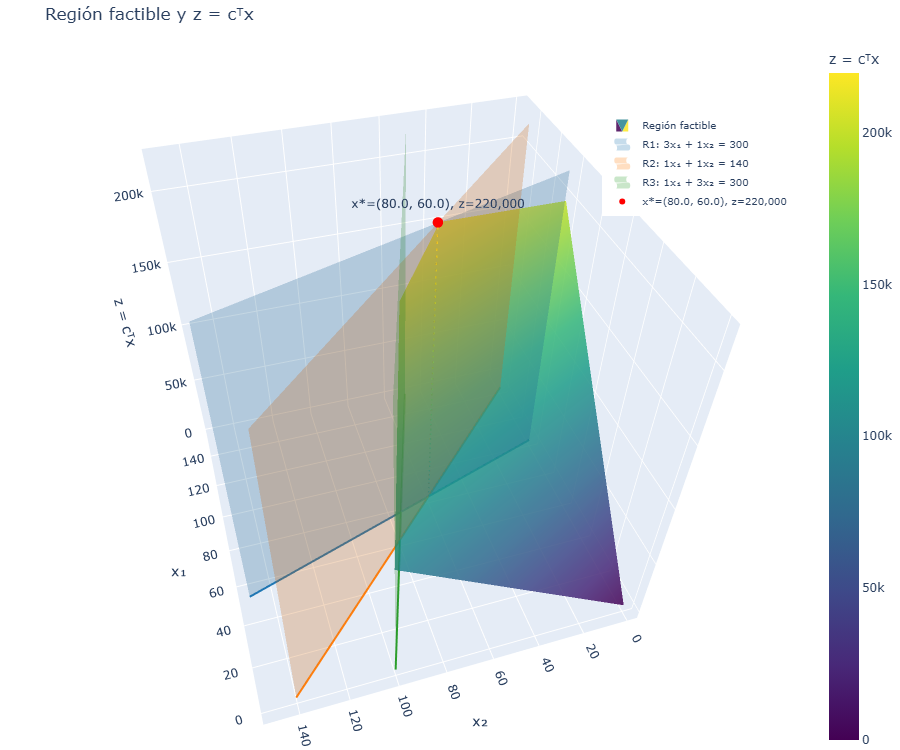

# 4) Análisis de sensibilidad

En general, la idea del análisis de sensibilidad en nuestro problema de optimización lineal consiste en determinar cuánto pueden cambiar los datos de entrada del problema sin que cambie el punto óptimo o la base óptima.

Resulta conveniente entender que esta idea proviene del hecho de agregar realismo al modelo matemático que representa el problema, pues en aplicaciones reales, es posible que hayan cambios en costos y/o recursos bajo la misma estructura inicial. Específicamente, esto implica perturbar los vectores $b$ y $c$ del problema pues son los que representan ambos parámetros. Además, los objetivos de cada análisis de sensibilidad son similares pero no son el mismo:
- El análisis de sensibilidad sobre $b$ responde la pregunta ¿cuánto puede cambiar $b$ para que se mantenga la base óptima original?
- El análisis de sensibilidad sobre $c$ responde la pregunta ¿cuánto puede cambiar $c$ para que se mantenga el punto óptimo original?

Dichas preguntas son diferentes por la estructura matemática del problema:
- $c$ es el vector de costos de la función objetivo $z=c_1x_1 + c_2x_2 = c^Tx$, por lo que variarlo resulta simplemente en rotaciones del plano (por ser $z \geq 0$ ya que $x \geq 0$ y $c \geq 0$), lo cual resulta en diferentes valores de $z$ para las mismas coordenadas de $x$.
- $b$ es el vector de recursos de las restricciones $Ax \leq b$, por lo que variarlo resulta en trasladar paralelamente cada frontera de cada restricción lineal, resultando en la compresión o expansión de la región factible. Esto implica que las coordenadas del óptimo puedan cambiar, pero que se mantenga la base óptima.

## Metodología propuesta

Teóricamente, existe un análisis clásico determinístico en donde se hacen cambios en cada componente de los vectores $b$ y $c$ mientras el resto de datos se mantienen fijos y se llegan a cotas que definen intervalos para los cuales se mantiene cada condición de óptimo particular. Sin embargo, este análisis es claramente 1D en el sentido de que las variaciones son hechas componente por componente y asumiendo los demás fijos.

Esto es un análisis útil pero poco realista, pues en aplicaciones reales las variaciones son menos ideales y es posible que ocurran sobre múltiples componentes a la vez, en otras palabras, las variaciones tienen incertidumbre. Por esto, quizás puede ser más conveniente variar todos los componentes del vector en diferentes magnitudes y luego evaluar el efecto del cambio (si se mantiene el óptimo o la base). Específicamente, se modela el cambio en cada vector como la adición de un componente estocástico, lo cual resulta en los vectores aleatorios

\begin{gather*}
b = b^* + \varepsilon_b b^* \quad\text{con}\; \varepsilon_b \sim \mathbb{U}(-\delta, \delta),\\
c = c^* + \varepsilon_c c^* \quad \text{con}\; \varepsilon_c \sim \mathbb{U}(-\delta, \delta)
\end{gather*}

Donde
- $\delta \in [0, E]$ es un real proveniente de un intervalo equiespaciado que representa el nivel de ruido o cambio aleatorio que se hace sobre el vector original $b^*$ o $c^*$, y $E$ es el nivel de ruido máximo que se quiere simular.
- $\mathbb{U}(-\delta, \delta)$ es una distribución uniforme multivariada sobre el intervalo. Note que dicho intervalo es simétrico e incluye valores negativos, pues los componentes del vector pueden aumentar o disminuir.
- $\varepsilon_b, \varepsilon_c$ son independientes e idénticamente distribuidos (iid).

La idea es tomar cada vector aleatorio resultante y revisar si se cumple cada condición:
- si el punto óptimo $x^*$ se mantiene con el nuevo $c$.
- si la base óptima $\mathcal{B}^*$ se mantiene con el nuevo $b$.

Como el enfoque es estilo Monte Carlo, la idea es repetir este procedimiento por un número grande de iteraciones $N$ para aprovecharnos de la Ley de los Grandes Números y garantizar que, al repetir el experimento muchas veces, el promedio de los resultados se acerque al valor esperado real.

En un alto nivel, la metodología se resume en: para cada nivel de ruido $\delta$, se simulan $N$ vectores $b$ y $c$, se cuenta por separado el número de veces que se cumple cada respectiva condición y esto permite calcular las probabilidades frecuencialistas:

\begin{gather*}
\mathbb{P}(c \text{ mantiene } x^*) = \frac{\text{# veces que ocurre}}{N},\\
\mathbb{P}(b \text{ mantiene } \mathcal{B}^*) = \frac{\text{# veces que ocurre}}{N},
\end{gather*}

Las cuales se pueden graficar versus cada nivel de ruido $\delta$, permitiendo evaluar la robustez del modelo ante diferentes amplitudes de cambio aleatorio.

**¿Qué condición se debe cumplir para que el óptimo se mantenga con el nuevo $c$, o para que la base óptima se mantenga con el nuevo $b$?**

Sabemos que nuestra función objetivo es de la forma:
\begin{gather*}
z^* = c_1x_1^* + c_2x_2^* \Rightarrow x_2^* = \frac{z^*}{c_2}-\frac{c_1}{c_2}x_1^*
\end{gather*}
con $c_1=2000$ y $c_2=1000$ en este caso. Por otro lado, como la base óptima fue $\mathcal{B^*}=\{x_1^*, x_2^*, s_3\}$, sabemos que las restricciones 1 y 3 son las activas:

\begin{gather*}
3x_1^* + x_2^* = 300 \Rightarrow x_2^* = 300-3x_1^* \Rightarrow \frac{c_1}{c_2}=3 \\
x_1^* + x_2^* = 140 \Rightarrow x_2^* = 140-x_1^* \Rightarrow \frac{c_1}{c_2}=1
\end{gather*}

Para mantener el óptimo $x^*$ debe cumplirse que la relación de las pendientes de la función objetivo $\frac{c_1}{c_2}$ se mantenga entre estos 2 valores (pues es la única manera de garantizar que se cumplen estas restricciones), entonces la condición de que el óptimo se mantenga bajo cambios de $c$ es:
\begin{equation}
1 \leq \frac{c_1}{c_2} \leq 3 \quad \text{(1)}
\end{equation}

Por otro lado, la base óptima $\mathcal{B^*}=\{x_1^*, x_2^*, s_3\}$ se mantiene bajo cambios de $b$ siempre que:
\begin{equation}
x_1^*, x_2^*, s_3 \geq 0 \quad \text{(2)}
\end{equation}

In [13]:
# Semilla aleatoria para reproducibilidad
np.random.seed(42)

# Inversa de la A_B donde la base óptima es {x_1, x_2, s_3}
A_B_inv = np.linalg.inv(A[:-1,])

def sensibilidad_monte_carlo(niveles_ruido, n_muestras=20000):
  prob_c_optimo = []
  prob_b_optimo = []

  for delta in niveles_ruido:
      # -------------------------------------------------------------
      # 1. Análisis estocástico del vector de costos c
      # Perturbar componentes c1 y c2 iid ~ Uniform[-delta, +delta]
      # -------------------------------------------------------------
      c_ruido = np.random.uniform(-delta, delta, size=(n_muestras, 2))
      c_simulado = c * (1.0 + c_ruido)

      # Condición: x* se mantiene como el óptimo sii 1 <= (c1 / c2) <= 3
      costo_relativo = c_simulado[:, 0] / c_simulado[:, 1]
      c_valido = (costo_relativo >= 1.0) & (costo_relativo <= 3.0)
      prob_c_optimo.append(np.mean(c_valido))

      # ------------------------------------------------------------------
      # 2. Análisis estocástico del vector de recursos b
      # Perturbar componentes b1, b2, and b3 iid ~ Uniform[-delta, +delta]
      # ------------------------------------------------------------------
      b_ruido = np.random.uniform(-delta, delta, size=(n_muestras, 3))
      b_simulado = b * (1.0 + b_ruido)

      # Calcular el nuevo punto óptimo x* = A_B^(-1) * b_B
      b_B = b_simulado[:, :2]  # b1, b2
      x_optimo = (A_B_inv @ b_B.T).T  # Dimensiones (n_muestras, 2)

      # Calcular la holgura de la base usando la restricción inactiva, s3 = b3 - (x1 + 3*x2)
      s3 = b_simulado[:, 2] - (x_optimo[:, 0] + 3.0 * x_optimo[:, 1])

      # Condición: la base {x1, x2, s3} óptima se mantiene sii x1 >= 0, x2 >= 0, s3 >= 0
      b_valid = (x_optimo[:, 0] >= 0) & (x_optimo[:, 1] >= 0) & (s3 >= 0)
      prob_b_optimo.append(np.mean(b_valid))

  return np.array(prob_c_optimo), np.array(prob_b_optimo)

In [14]:
# Correr la simulación
niveles_ruido = np.linspace(0.0, 0.45, 100) # vector equiespaciado de ruido con 100 muestras de [0, 0.45]
prob_c, prob_b = sensibilidad_monte_carlo(niveles_ruido)

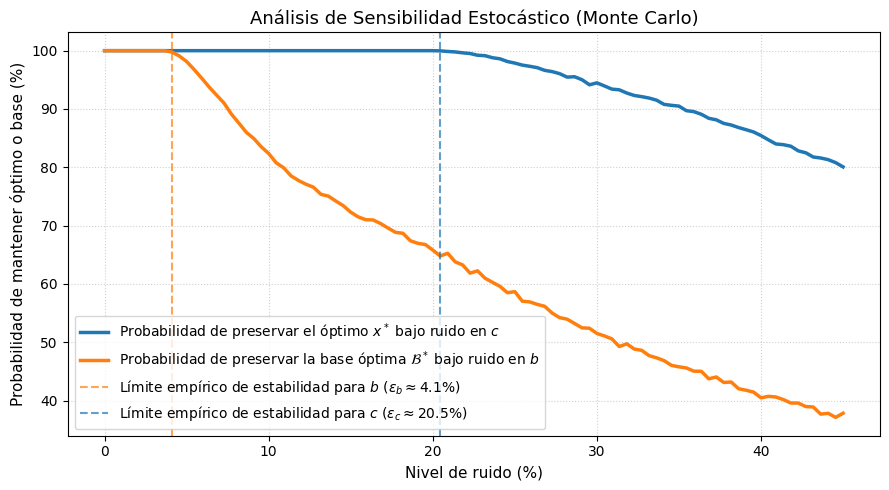

In [15]:
# Graficar los resultados
plt.figure(figsize=(9, 5))

# Curvas de probabilidad vs nivel de ruido
plt.plot(niveles_ruido * 100, prob_c * 100, label=r'Probabilidad de preservar el óptimo $x^*$ bajo ruido en $c$', lw=2.5)
plt.plot(niveles_ruido * 100, prob_b * 100, label=r'Probabilidad de preservar la base óptima $\mathcal{B}^*$ bajo ruido en $b$', lw=2.5)

# Encontrar el nivel de ruido máximo para el cual se cumplen las condiciones con
# probabilidad del 100%
break_b = niveles_ruido[np.argmin(prob_b == 1.0)] * 100
break_c = niveles_ruido[np.argmin(prob_c == 1.0)] * 100

# Graficar estos niveles como líneas punteadas del color de cada respectiva curva
plt.axvline(x=break_b, color='#ff7f0e', linestyle='--', alpha=0.7,
            label=r'Límite empírico de estabilidad para $b$ ($\varepsilon_b \approx$' + f'{break_b:.1f}%)')
plt.axvline(x=break_c, color='#1f77b4', linestyle='--', alpha=0.7,
            label=r'Límite empírico de estabilidad para $c$ ($\varepsilon_c \approx$' + f'{break_c:.1f}%)')

plt.title("Análisis de Sensibilidad Estocástico (Monte Carlo)", fontsize=13)
plt.xlabel("Nivel de ruido (%)", fontsize=11)
plt.ylabel("Probabilidad de mantener óptimo o base (%)", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower left', frameon=True)
plt.tight_layout()
plt.show()

# Análisis
En general, podemos observar que el modelo es más robusto ante cambios del vector $c$ que del vector $b$, es decir, fue más fácil preservar el óptimo (azul) que preservar la base óptima (naranja) o, en otras palabras, es más sensible ante cambios el vector de recursos $b$ que el vector de costos $c$.

- Siendo formales, esto lo podemos evidenciar viendo los límites empíricos de estabilidad, los cuales indican que en las $20000$ muestras (experimentos) el óptimo $x^*$ se logra preservar el $100\%$ de las veces hasta alcanzar un nivel de ruido de $\varepsilon_b \approx 20.5\%$ (línea punteada azul), donde valores posteriores implican menor probabilidad de preservarlo, aumentando la probabilidad de caer en escenarios donde las coordenadas óptimas cambian (nuevo vertice). En el caso de la base óptima $\mathcal{B^*}$, se logró mantener el $100\%$ de las veces hasta alcanzar un nivel de ruido de $\varepsilon_b \approx 4.1\%$ (línea punteada naranja), donde valores posteriores implicaron una menor probabilidad de preservarla, aumentando la probabilidad de caer en escenarios donde la base cambia (nuevas combinaciones de restricciones activas).
- Aunque ambas probabilidades disminuyen proporcional al nivel de ruido, se observa que la probabilidad de preservar la base óptima (en naranja) disminuye más rápido y de manera exponencial, mientras que la probabilidad de preservar el óptimo (en azul) disminuye más lento y aproximadamente lineal.